# 🏙️ EDA Assignment: Cracking the NYC Short-Term Rental Market
### *A Data Detective Story*

---

**Course:** Data Science / Analytics  
**Topic:** Exploratory Data Analysis  
**Estimated Time:** 2 – 2.5 hours  
**Total Marks:** 100

---

## 📖 Background & Case Study

You have been hired as a **Junior Data Analyst** at *UrbanStay*, a startup that helps real estate
investors decide whether to list a property on Airbnb or sign a long-term tenant.
Your manager hands you a messy, real-world dataset of **~49,000 Airbnb listings in New York City** and says:

> *We have three investors coming in Friday. One wants to buy in Manhattan, one is eyeing Brooklyn,
> and one has no idea. Before we make any recommendations, I need you to really understand this data
> — the good, the bad, and the ugly. EDA only, no ML yet.*

Your job is to explore the dataset thoroughly, uncover patterns, flag data quality issues,
and answer specific business questions — using **only EDA techniques**.

---

## 📦 The Dataset

**Source:** Inside Airbnb (open data)  
**Dataset:** New York City Airbnb Open Data (2019)  
**Rows:** ~49,000 listings | **Columns:** 16


In [1]:
# ── SETUP: Run this cell first ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── LOAD DATA ────────────────────────────────────────────────────────────────
# URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/AB_NYC_2019.csv"
df = pd.read_csv(r"U:/AB_NYC_2019.csv")

print(f"Data loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


Data loaded successfully!
Shape: 48,895 rows x 16 columns


---

## 🗂️ Column Reference

| Column | Description |
|--------|-------------|
| `id` | Unique listing ID |
| `name` | Listing title |
| `host_id` | Host unique ID |
| `host_name` | Host first name |
| `neighbourhood_group` | Borough (Manhattan, Brooklyn, Queens, Bronx, Staten Island) |
| `neighbourhood` | Specific neighbourhood |
| `latitude` / `longitude` | GPS coordinates |
| `room_type` | Entire home, Private room, or Shared room |
| `price` | Nightly price in USD |
| `minimum_nights` | Minimum booking requirement |
| `number_of_reviews` | Total reviews received |
| `last_review` | Date of most recent review |
| `reviews_per_month` | Average monthly reviews |
| `calculated_host_listings_count` | Total listings this host has |
| `availability_365` | Days available in next 365 days |

---

## ⚠️ Ground Rules

1. Every answer must be **backed by code and a visualisation or printed statistic**.
2. Write your **interpretation** in the Markdown cell below each task.
3. No machine learning. No predictive models. EDA only.
4. Plots must have **titles, axis labels, and legends** where appropriate.
5. All cells must run **top-to-bottom without errors**.

---


# 🔎 PART 1 — First Contact with the Data
### (15 Marks)

Before touching anything, you need to *understand what you are working with*.


### Task 1.1 — Initial Inspection (5 marks)

Display the first few rows, data types, and summary statistics.

Then answer:
- How many numerical vs categorical columns are there?
- Does anything **immediately** look suspicious or unexpected?

> 💡 *Hint: There are multiple pandas methods designed exactly for this.
> Think about what a doctor does before diagnosing — they observe first.*


In [4]:
# Your code here
print("Displaying first five rows: ")
df.head()

print("Data Types:")
df.info()

print("Summary Statistics:")
df.describe()

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns:", num_cols)
print("Count:", len(num_cols))

cat_cols = df.select_dtypes(include=['object', 'category']).columns
print("Categorical columns:", cat_cols)
print("Count:", len(cat_cols))



Displaying first five rows: 
Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int6

**✍️ Your Interpretation:**  
there are 10 numerical and 6 categorical columns in this dataset

### Task 1.2 — Missing Value Audit (5 marks)

Identify **all missing values** across every column.
Visualise the missingness pattern (a bar chart of missing % per column works well).

Then answer:
- Which columns have missing data and what % is missing?
- For each missing column, *why* might the data be absent? Is it random or does it make business sense?
- What would you recommend doing about each? (Do not act yet — just recommend.)

> 💡 *Hint: Missing data is almost never random.
> Think carefully about when `reviews_per_month` would logically be empty.*


Checking missing values for each column:
id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64


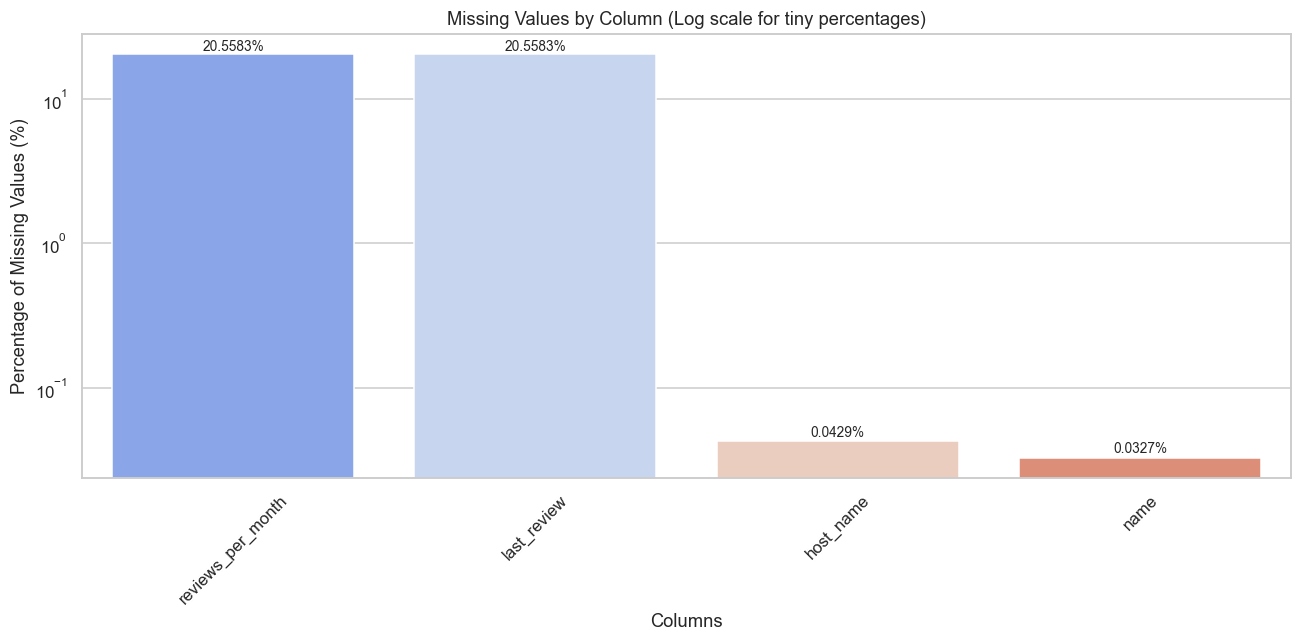

In [5]:
# Your code here
print("Checking missing values for each column:")

missing_counts = df.isna().sum()
missing_percent = df.isna().sum() / len(df) * 100
print(missing_counts)
# Keep only columns that have missing values
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

# 2️⃣ Create a bar chart
plt.figure(figsize=(12,6))
ax = sns.barplot(x=missing_percent.index, y=missing_percent.values, palette='coolwarm')

# Show percentage above bars
for i, v in enumerate(missing_percent.values):
    ax.text(i, v + 0.001, f"{v:.4f}%", ha='center', va='bottom', fontsize=9)

plt.xlabel('Columns')
plt.ylabel('Percentage of Missing Values (%)')
plt.title('Missing Values by Column (Log scale for tiny percentages)')
plt.yscale('log')  # logarithmic y-axis
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**✍️ Your Interpretation:**  

For 1 and 2: host_name and name have missing values, which indicate that these are mistakenly left unfilled, whereas, the two columns, last_review and reviews_per_month are not left with mistake as empty, they have never been reviewed and we do not need to drop them because these are the real listings.

For 3: a recoomendation is that to fill the unfilled reviews_per_month and last_review with some unanswered value and drop the records having unfilled host_name and names in the dataset

### Task 1.3 — Duplicate Check (5 marks)

Check for duplicate rows. Also verify whether `id` (listing ID) is truly unique.
Report any anomalies you find.

> 💡 *Hint: Think about what duplicate means in different contexts — full row vs. key column.*


In [8]:
# Your code here
duplicate_rows = df.duplicated().sum()
print(f"Number of full-row duplicates: {duplicate_rows}")
print()
print(df[df.duplicated()])

id_unique_count = df['id'].nunique()
total_rows = len(df)

print(f"\nTotal rows: {total_rows}")
print(f"Unique listing IDs: {id_unique_count}")

if id_unique_count == total_rows:
    print("✅ Each listing ID is unique — no duplicates.")
else:
    print(f"⚠️ There are {total_rows - id_unique_count} duplicate IDs!")
    duplicate_ids = df[df.duplicated(subset=['id'], keep=False)]
    print(duplicate_ids[['id']])


Number of full-row duplicates: 0

Empty DataFrame
Columns: [id, name, host_id, host_name, neighbourhood_group, neighbourhood, latitude, longitude, room_type, price, minimum_nights, number_of_reviews, last_review, reviews_per_month, calculated_host_listings_count, availability_365, price_log]
Index: []

Total rows: 48895
Unique listing IDs: 48895
✅ Each listing ID is unique — no duplicates.


**✍️ Your Interpretation:**  
there are two checks for duplication here, one for duplicate row(in which all attributes for two records have same values) and another for duplicate id(in which two records have the same unique/primary key values, which is another anomaly).

upon inspection, we come to know that there are neither of these two anomalies in our dataset

---

# 💰 PART 2 — The Price Puzzle
### (25 Marks)

Price is the most important variable for your investors.
Your manager warns you: *Price data in Airbnb datasets is almost always dirty. Tread carefully.*


### Task 2.1 — Price Distribution (8 marks)

Plot the distribution of `price`. Then plot it again after applying an appropriate transformation.

Answer:
- What is the shape of the original distribution? Use correct statistical terms.
- Are there listings with a price of **$0**? How many? What should you do with them?
- After handling $0 listings, what does the distribution look like? What is a typical price?

> 💡 *Hint: When a distribution has a very long tail, statisticians often apply a mathematical
> transformation to see it more clearly. What transformation works well for right-skewed, positive data?*


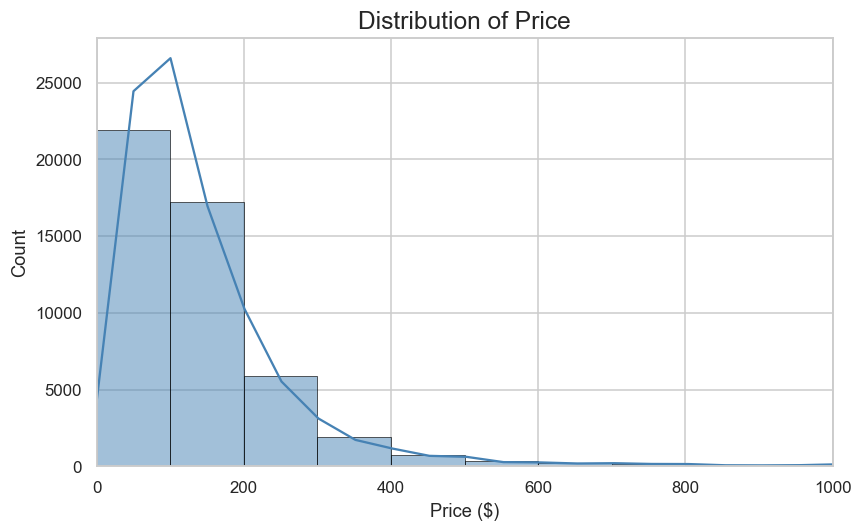

After applying log transformation on price


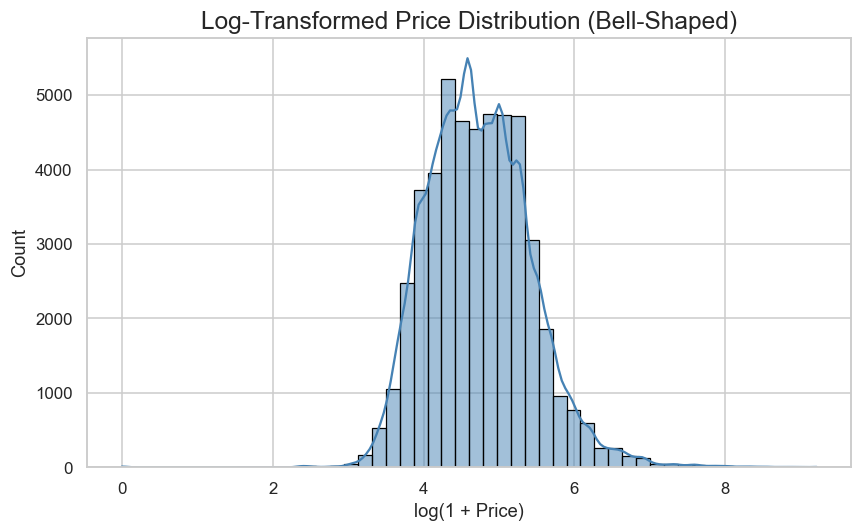

In [11]:
# Your code here
plt.figure(figsize=(8, 5))

# Histogram + KDE
sns.histplot(df['price'], bins=100, kde=True, color='steelblue', edgecolor='black')

plt.title('Distribution of Price', fontsize=16)
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.xlim(0, 1000) 
plt.tight_layout()
plt.show()


print("After applying log transformation on price")
df['price_log'] = np.log1p(df['price'])  # log(1 + price) handles zeros


# Plot histogram + KDE
plt.figure(figsize=(8, 5))
sns.histplot(df['price_log'], bins=50, kde=True, color='steelblue', edgecolor='black')

plt.title('Log-Transformed Price Distribution (Bell-Shaped)', fontsize=16)
plt.xlabel('log(1 + Price)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**✍️ Your Interpretation:**  
the shape of the original distribution is right skewed, which shows that more houses have smaller price values in the dataset and very fewer have larger price values, which makes the distribution asymmetric.
for right skewed data, log transformation works well, because it compresses large values and spreads small ones, making the distribution more symmetric and easier to analyze. this results in a symmetric, gaussian distribution/bell curve. 
log(1+x), 1 is added if there is any x=0, then it can be handled 

### Task 2.2 — Price by Borough (9 marks)

Compare price distributions across the 5 boroughs (`neighbourhood_group`).
Use **at least two different plot types**.

Answer:
- Which borough is most expensive on **median** price? Which on **mean**? Are they the same borough? Why might they differ?
- Which borough has the most price variability? What does that mean for an investor?
- Where are outliers most extreme?

> 💡 *Hint: Mean and median tell different stories.
> A box plot and a violin plot each reveal something the other does not.*


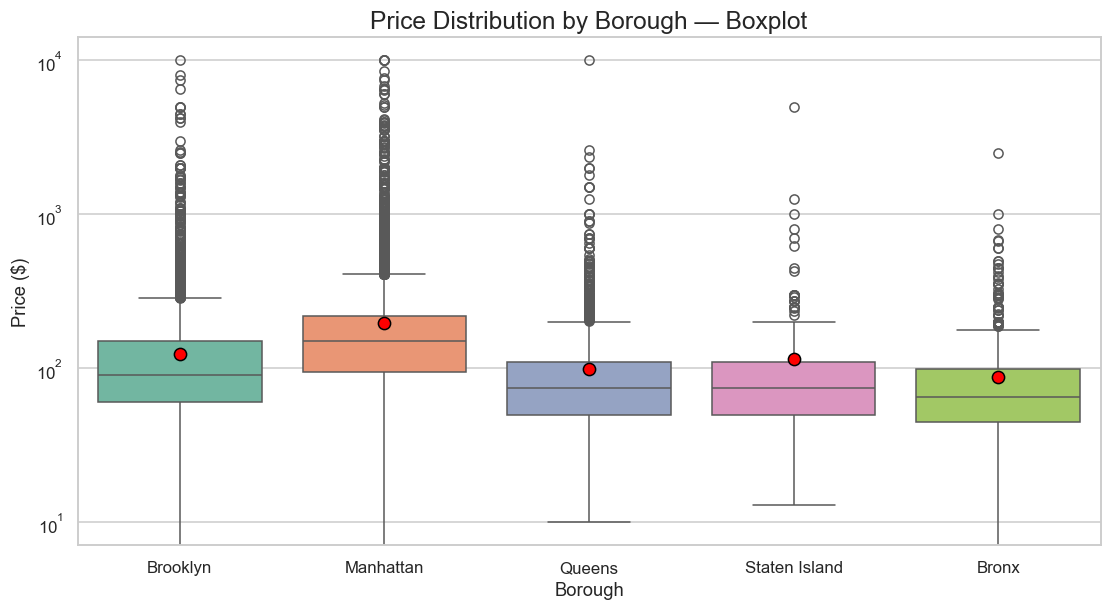

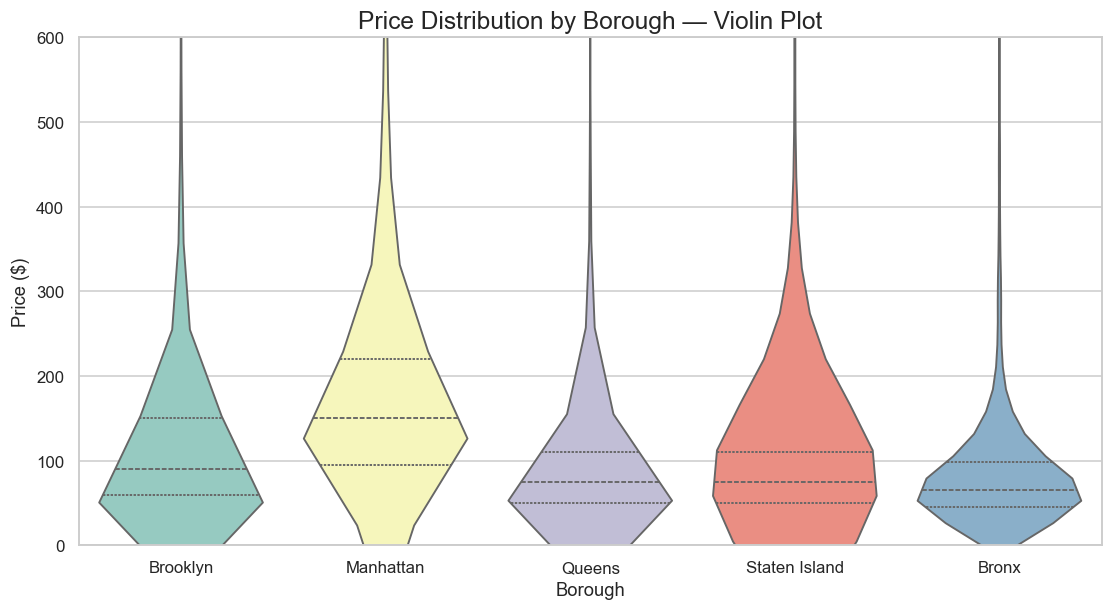

In [10]:
# Your code here
price_data=df['price']
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, 
    x='neighbourhood_group', 
    y='price', 
    palette='Set2', 
    showmeans=True,  # show mean marker
    meanprops={
        "marker": "o",       # marker shape
        "markerfacecolor": "red",  # color of mean marker
        "markeredgecolor": "black",
        "markersize": 8})
plt.title('Price Distribution by Borough — Boxplot', fontsize=16)
plt.ylabel('Price ($)')
plt.xlabel('Borough')

# plt.ylim(0, 500)
plt.yscale('log')
plt.show()

plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='neighbourhood_group', y='price', palette='Set3', inner='quartile')
plt.title('Price Distribution by Borough — Violin Plot', fontsize=16)
plt.ylabel('Price ($)')
plt.xlabel('Borough')
plt.ylim(0, 600)
plt.show()

**✍️ Your Interpretation:**  
Manhattan is most expensive on the mean price(seen from the red dot inside the boxplot).
Manhattan is most expensive on the median price(seen from the line inside the boxplot).
It is not necessary for mean and median to be on the same borough, median shows the typical listing price, mean is influenced by extreme expensive listings; they may differ if outliers exist.
Manhattan is also the most expensive on the median price(it has the longest violin on violin plot).
Look at the height of the box and whiskers (boxplot) or width/height of the violin; a taller box/longer violin means higher spread/variability.
The most extreme outliers are on Manhattan. 

Task 2.3 — Price by Room Type (8 marks)

Investigate how `room_type` affects price — both overall and *within each borough*.
A heatmap or grouped bar chart of **median prices** could work well.

Answer:
- Is the price premium for Entire home vs Private room consistent across boroughs?
- Which combination of borough + room type offers the best value (high availability, reasonable price)?

> 💡 *Hint: Pivot tables are your friend here.
> Think about what rows, columns, and values should represent.*


Median Price Pivot Table:



room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,100.0,53.5,40.0
Brooklyn,145.0,65.0,36.0
Manhattan,191.0,90.0,69.0
Queens,120.0,60.0,37.0
Staten Island,100.0,50.0,30.0


Median Availability Pivot Table:



room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Bronx,131.0,157.0,89.0
Brooklyn,28.0,24.0,156.0
Manhattan,42.0,29.0,81.0
Queens,89.0,108.0,175.5
Staten Island,176.5,282.0,37.0


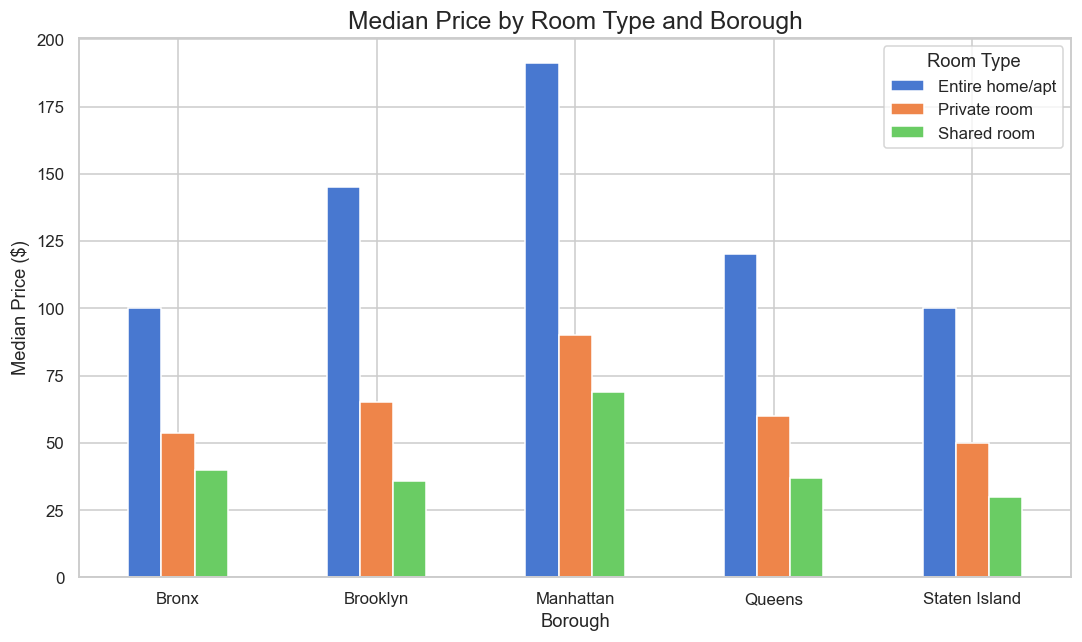

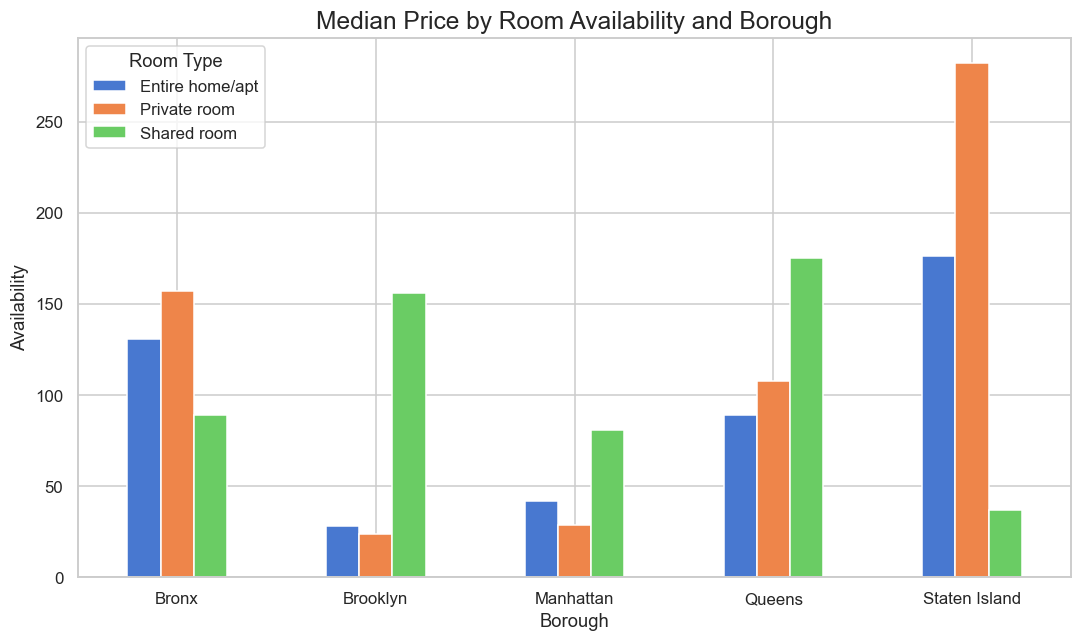

In [26]:


# 1️. Pivot table for median price
pivot_price = df.pivot_table(
    values='price',
    index='neighbourhood_group',   # boroughs
    columns='room_type',           # room types
    aggfunc='median'
)

print("Median Price Pivot Table:\n")
display(pivot_price)


# 2️. Pivot table for median availability
pivot_availability = df.pivot_table(
    values='availability_365',
    index='neighbourhood_group',   # boroughs
    columns='room_type',           # room types
    aggfunc='median'
)

print("Median Availability Pivot Table:\n")
display(pivot_availability)

# 3️. Plot grouped bar chart
plt.figure(figsize=(10,6))
pivot_price.plot(kind='bar', ax=plt.gca())  # make sure we use the current axes

plt.title("Median Price by Room Type and Borough", fontsize=16)
plt.xlabel("Borough", fontsize=12)
plt.ylabel("Median Price ($)", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Room Type")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
pivot_availability.plot(kind='bar', ax=plt.gca())  # make sure we use the current axes

plt.title("Median Price by Room Availability and Borough", fontsize=16)
plt.xlabel("Borough", fontsize=12)
plt.ylabel("Availability", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title="Room Type")
plt.tight_layout()
plt.show()

**✍️ Your Interpretation:**  

1. Yes, the pattern is consistent as entire homes are more expensive than private rooms across all boroughs.
Entire homes are consistently more expensive than Private rooms across all boroughs.
The premium is largest in Manhattan and smallest in Staten Island.

2. Staten Island private room offers the best value(best price, high availability), Brooklyn and Queens shared rooms also fall in this category of best value.

---

# 🏠 PART 3 — Host Behaviour & Market Structure
### (20 Marks)

Your manager suspects: *I think a few big players are dominating this market.
If that is true, it changes our advice to investors completely.*


### Task 3.1 — Host Concentration Analysis (10 marks)

Analyse the `calculated_host_listings_count` column.

- What % of hosts have **only 1 listing**? What % have **more than 10**?
- Plot the distribution of host listing counts (be careful with scale).
- Calculate: the top **1% of hosts** control what % of all listings?
- Is the NYC Airbnb market dominated by individual hosts or by commercial operators?

> 💡 *Hint: Think about how economists measure inequality.
> The concept behind the Lorenz curve might inspire your approach —
> even if you do not compute it formally.*


Percentage of hosts with 1 listing: 66.06605992432763
Percentage of hosts with >10 listings: 6.0681051232232335


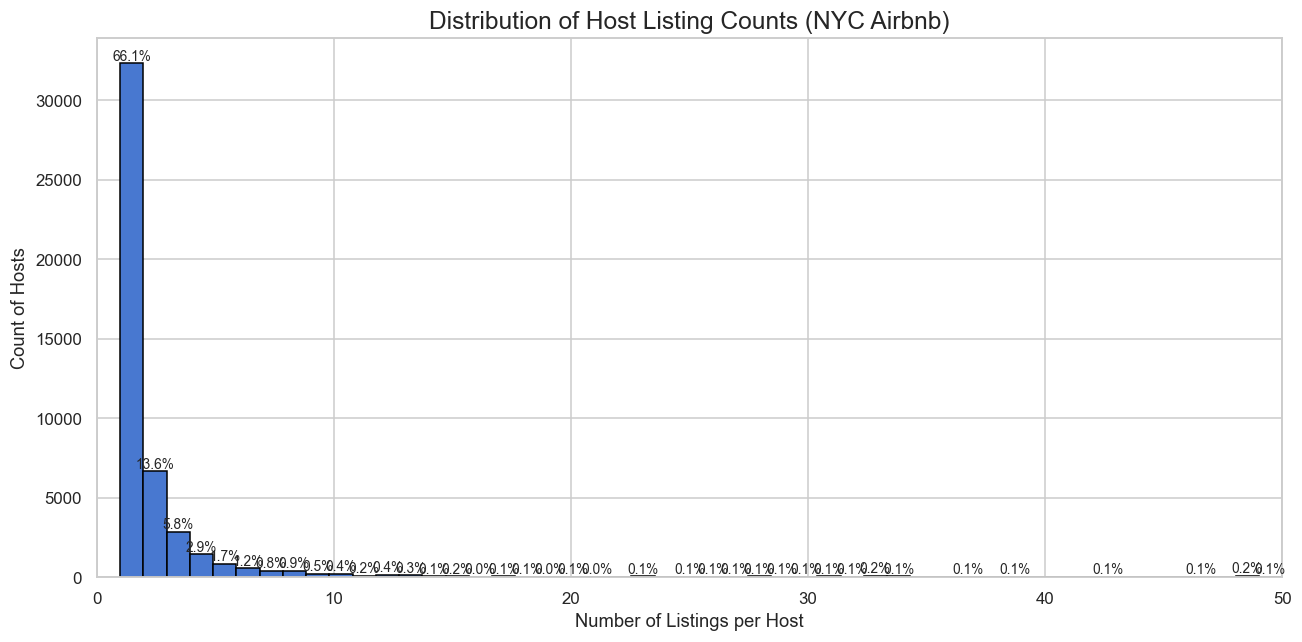

Top 1% hosts control: 10.105327743123018 % of listings


In [30]:
# 1. Percentage of hosts with 1 listing and greater than 10 listings
total_hosts = len(df)

hosts_one = (df['calculated_host_listings_count'] == 1).sum()
hosts_more10 = (df['calculated_host_listings_count'] > 10).sum()

pct_one = hosts_one / total_hosts * 100
pct_more10 = hosts_more10 / total_hosts * 100

print("Percentage of hosts with 1 listing:", pct_one)
print("Percentage of hosts with >10 listings:", pct_more10)

plt.figure(figsize=(12,6))

# 2. Compute histogram 
counts, bins, patches = plt.hist(df['calculated_host_listings_count'], bins=50, range=(1,50), edgecolor='black')
# counts: no of hosts in each bin
# patch: each bar of histogram, it has its x and y coordinates, width and height

# Convert counts to percentages of each bar
percentages = counts / total_hosts * 100

# Plot histogram
plt.title("Distribution of Host Listing Counts (NYC Airbnb)", fontsize=16)
plt.xlabel("Number of Listings per Host", fontsize=12)
plt.ylabel("Count of Hosts", fontsize=12)

# Add percentage labels above each bar
for patch, pct in zip(patches, percentages):
    height = patch.get_height()
    if height > 0:  # only label bars with height > 0
        plt.text(patch.get_x() + patch.get_width()/2, height + 5, f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)
        # get_x() gives the left starting point of bar on x axis and get_width()/2 gives half of the width of the bar,
        # together they give the center of the bar for the text to be placed on x-axis
        
plt.xlim(0,50)
plt.tight_layout()
plt.show()


# 3. Calculating top 1 percent of hosts control how much of the listings
hosts = df[['host_id','calculated_host_listings_count']].drop_duplicates()
hosts_sorted = hosts.sort_values(by='calculated_host_listings_count', ascending=False)
top1 = int(len(hosts_sorted) * 0.01)
top_hosts = hosts_sorted.head(top1)
top_listings = top_hosts['calculated_host_listings_count'].sum()
total_listings = hosts_sorted['calculated_host_listings_count'].sum()
share = (top_listings / total_listings) * 100
print("Top 1% hosts control:", share, "% of listings")

**✍️ Your Interpretation:**  
NYC Airbnb market is mostly individual hosts.
There is some concentration: a few commercial operators control more listings than the average host.
It’s not extreme domination, but market power is slightly skewed toward commercial operators.


### Task 3.2 — Activity vs Ghost Listings (10 marks)

The `last_review` column tells you when a listing was last reviewed.
Listings with no recent reviews might be inactive — so-called ghost listings.

- Convert `last_review` to datetime. Calculate days since last review relative to **2019-07-08** (snapshot date).
- What % of listings have had **no review in the past year**? Past 6 months?
- Is there a relationship between `availability_365` and review activity? Plot and interpret.
- Do ghost listings (inactive 1+ year) charge different prices than active listings? Compare distributions.

> 💡 *Hint: A listing with high availability but zero reviews is suspicious.
> What business scenario could explain that combination?*


Listings inactive for 1+ year: 19.82002249718785 %
Listings inactive for 6+ months: 30.088966151958278 %


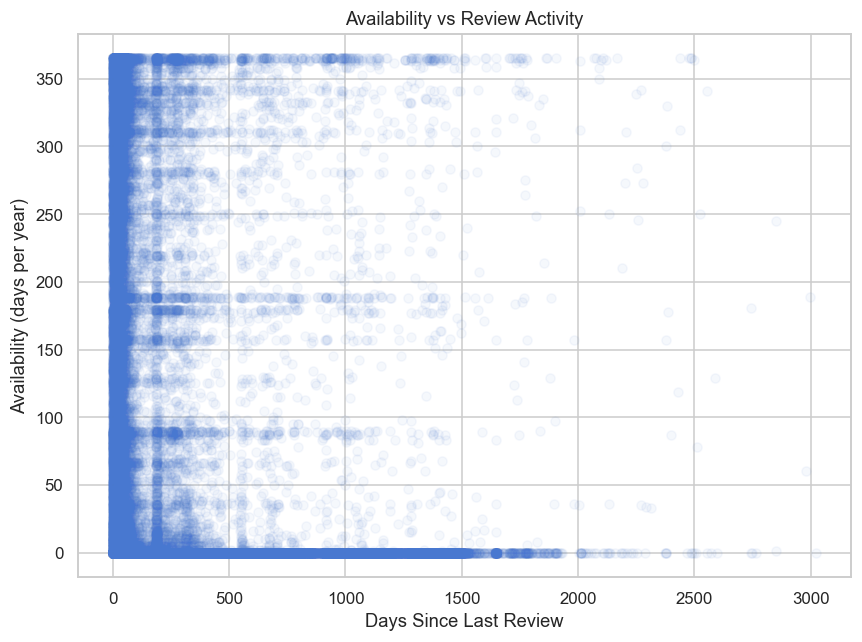

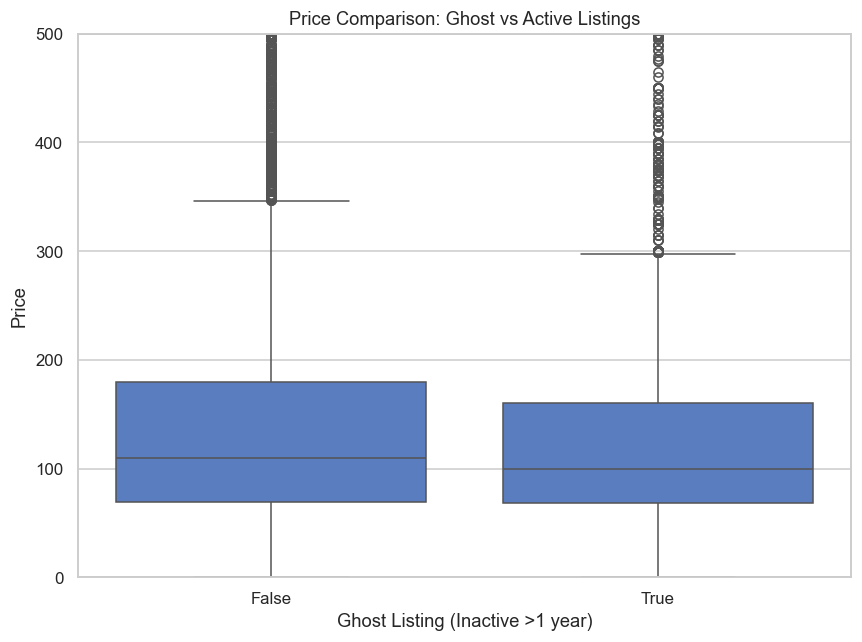

In [34]:
# Your code here
df['last_review'] = pd.to_datetime(df['last_review'])

snapshot_date = pd.to_datetime('2019-07-08')
df['days_since_review'] = (snapshot_date - df['last_review']).dt.days

ghost_year = (df['days_since_review'] > 365).mean() * 100
print("Listings inactive for 1+ year:", ghost_year, "%")
ghost_6months = (df['days_since_review'] > 180).mean() * 100
print("Listings inactive for 6+ months:", ghost_6months, "%")

plt.figure(figsize=(8,6))
plt.scatter(df['days_since_review'], df['availability_365'], alpha=0.05)
plt.title("Availability vs Review Activity")
plt.xlabel("Days Since Last Review")
plt.ylabel("Availability (days per year)")
plt.tight_layout()
plt.show()

df['ghost_listing'] = df['days_since_review'] > 365
plt.figure(figsize=(8,6))
sns.boxplot(x='ghost_listing', y='price', data=df)
plt.title("Price Comparison: Ghost vs Active Listings")
plt.xlabel("Ghost Listing (Inactive >1 year)")
plt.ylabel("Price")
plt.ylim(0,500)  # remove extreme outliers
plt.tight_layout()
plt.show()

**✍️ Your Interpretation:**  


1. There are some properties for which have many days have passed since they were last reviewed, which shows a normal trend, but there is also a very small percentage of properties that have high availability throughout the year and are not reviewd regularly, such as, host stopped renting but did not remove the listing or some other reasons, so nobody books them, but overall, the trend is quite positive.

2. Active listings tend to be more expensive than ghost listings.
Ghost listings(inactive for 1+ year and representing true on the box plot) have a lower median price compared to active listings. This suggests that active listings may be located in higher-demand areas or offer better quality accommodations, allowing them to charge higher prices. In contrast, ghost listings may remain inactive due to lower demand or other issues despite their lower prices.



---

# 🗺️ PART 4 — Geographic Deep Dive
### (20 Marks)

Location is everything in real estate.
Your investors will ask: *Where exactly should we buy?*


### Task 4.1 — Neighbourhood Density & Pricing (10 marks)

- Find the **Top 10 neighbourhoods** by listing count. Visualise.
- For those top 10, plot their **median price**. Is listing density correlated with price?
- Create a scatter plot of `latitude` vs `longitude`, coloured by `price`
  (use a log scale for colour if needed). What geographic pattern do you observe?

> 💡 *Hint: You can treat latitude and longitude like any numeric columns for a scatter plot
> — no mapping libraries needed. The shape of NYC will emerge from the data itself.*


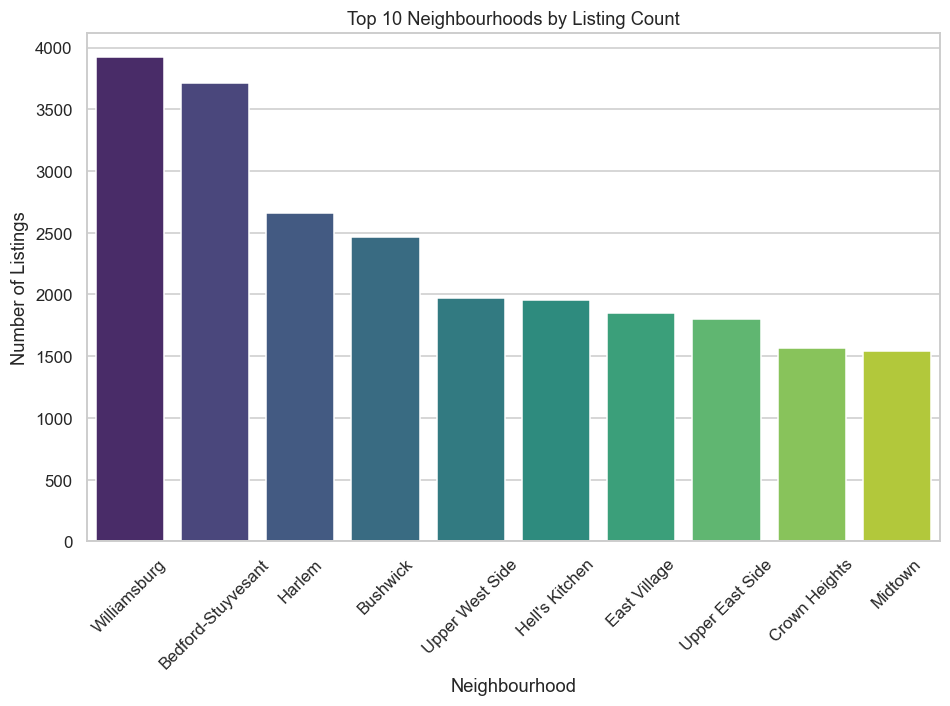

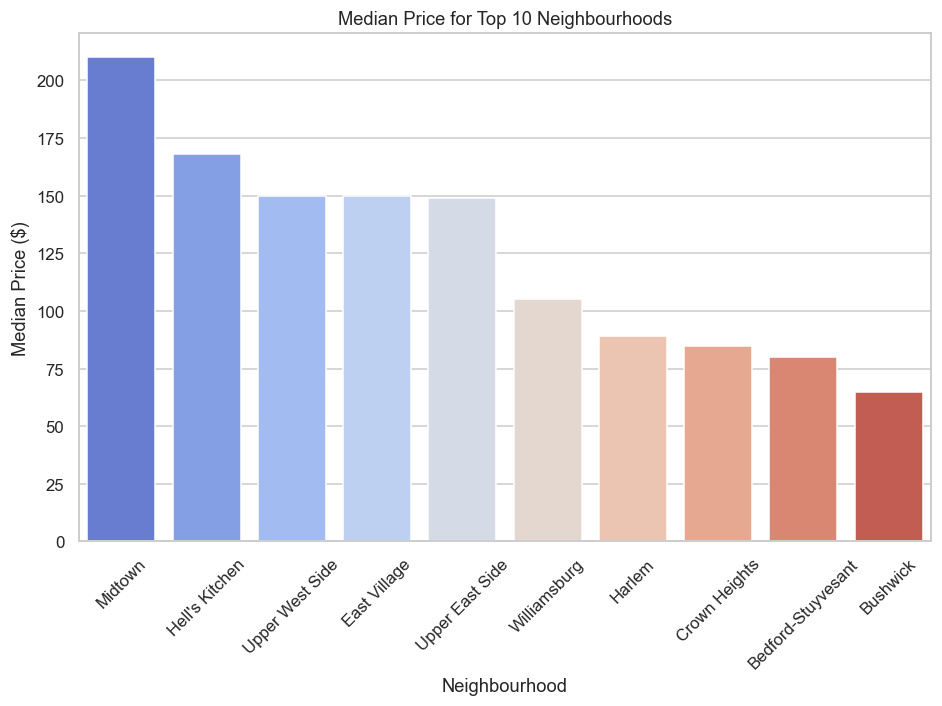

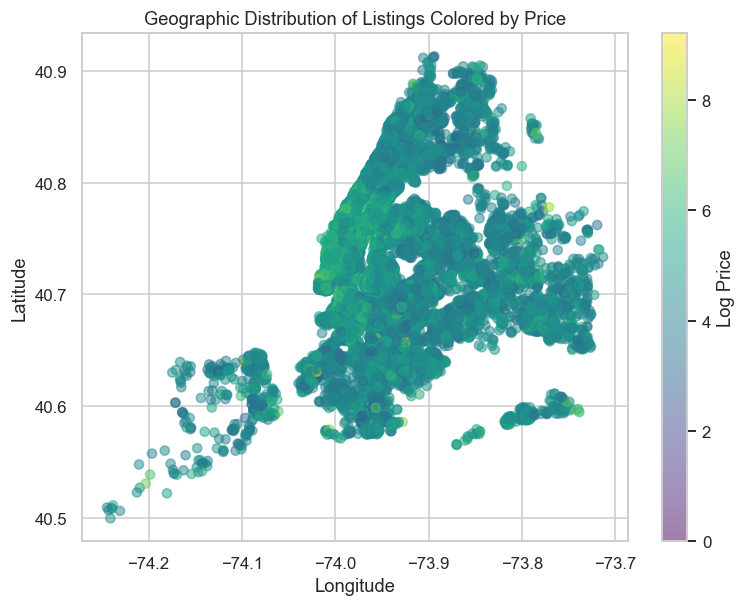

In [42]:
# 1. 
top10_neigh = df['neighbourhood'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top10_neigh.index, y=top10_neigh.values, palette='viridis')

plt.title('Top 10 Neighbourhoods by Listing Count')
plt.xlabel('Neighbourhood')
plt.ylabel('Number of Listings')

plt.xticks(rotation=45)
plt.show()

# 2.
top10_names = top10_neigh.index

median_prices = df[df['neighbourhood'].isin(top10_names)].groupby('neighbourhood')['price'].median().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=median_prices.index, y=median_prices.values, palette='coolwarm')

plt.title('Median Price for Top 10 Neighbourhoods')
plt.xlabel('Neighbourhood')
plt.ylabel('Median Price ($)')

plt.xticks(rotation=45)
plt.show()

# 3.
plt.figure(figsize=(8,6))

plt.scatter(
    df['longitude'],
    df['latitude'],
    c=np.log1p(df['price']),   # log scale for price
    cmap='viridis',
    alpha=0.5
)

plt.colorbar(label='Log Price')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Listings Colored by Price')

plt.show()

**✍️ Your Interpretation:**  

1. No, listing density is not correlated with price, a higher listing density does not correspond to a higher price, for instance, Williamsburg has highest listings but its median price is not the highest, but is lesser than that of Midtown, Hell's Kitchen and some other boroughs. Similarly, Bushwick has more listings thanUpper West Kitchen, Hell's Kitchen and East Side, but its median price is the lowest among the top 10 neighbourhoods.
2. Neighbourhoods with many dots in the scatter plot indicate higher listing density and generally higher prices. These are areas with higher latitude and longitude. These locations correspond to central areas of New York City where prices are typically higher.

### Task 4.2 — The minimum_nights Anomaly (10 marks)

Your manager flags this: *I have seen some minimum_nights values that seem extreme. Can you investigate?*

- Plot the distribution of `minimum_nights`. What do you find?
- What % of listings require **30+ nights** minimum? **365 nights**?
  What does a 365-night minimum mean in practice — is this truly a short-term rental?
- Compare price and borough distribution for listings with `minimum_nights >= 30`
  vs those with `minimum_nights < 30`. Are they a different product category?
- Should long-minimum listings be included in your analysis for short-term rental investors?
  Make a clear recommendation.

> 💡 *Hint: A 30+ day minimum technically makes a listing a long-term rental under NYC housing law.
> That changes the regulatory picture entirely.*


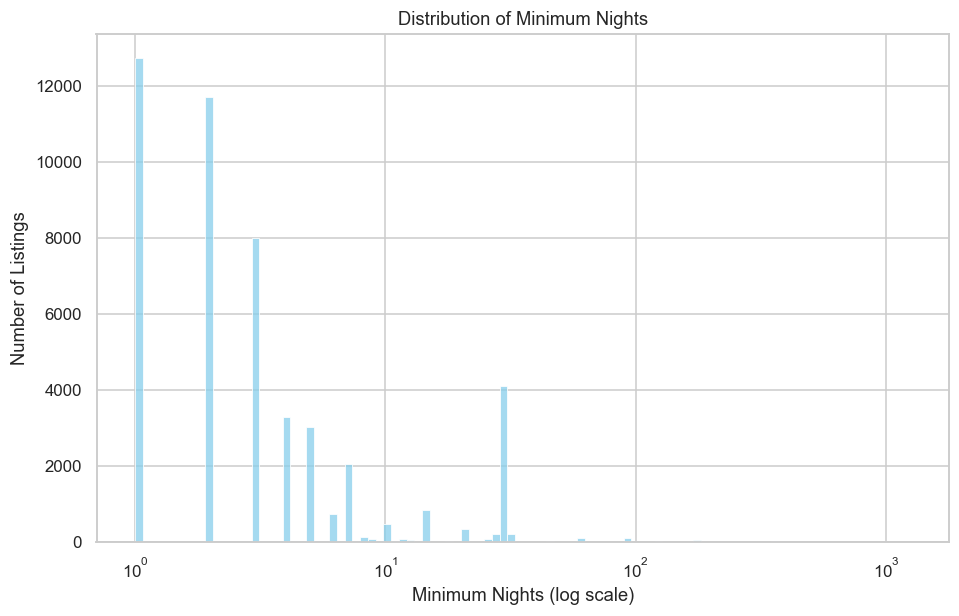

% of listings with minimum_nights >= 30: 9.22%
% of listings with minimum_nights = 365: 0.06%


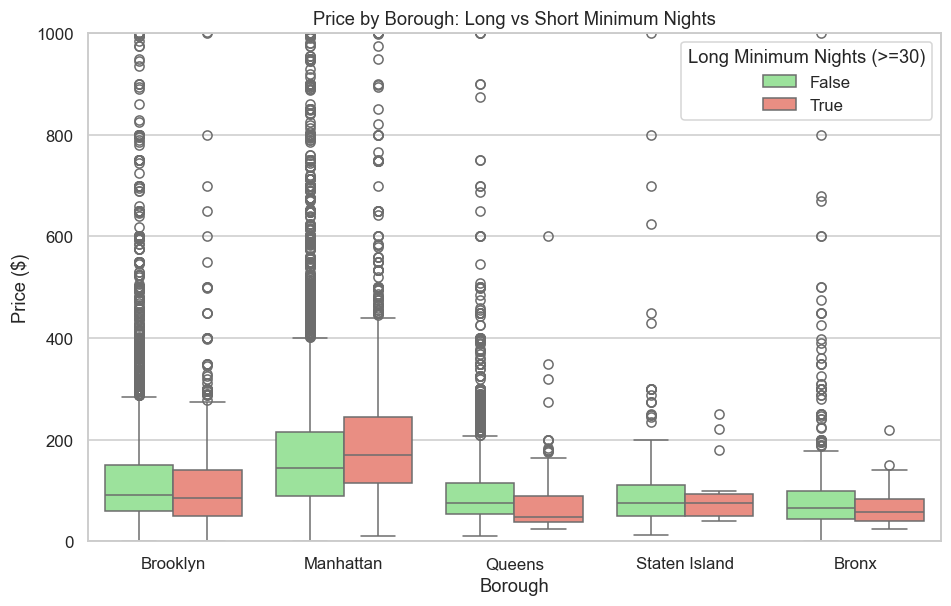

In [46]:
# Your code here
# 1.
plt.figure(figsize=(10,6))
sns.histplot(df['minimum_nights'], bins=100, log_scale=(True, False), color='skyblue')
plt.xlabel('Minimum Nights (log scale)')
plt.ylabel('Number of Listings')
plt.title('Distribution of Minimum Nights')
plt.show()

# 2.
total_listings = len(df)
pct_30plus = (df['minimum_nights'] >= 30).sum() / total_listings * 100
pct_365 = (df['minimum_nights'] == 365).sum() / total_listings * 100

print(f"% of listings with minimum_nights >= 30: {pct_30plus:.2f}%")
print(f"% of listings with minimum_nights = 365: {pct_365:.2f}%")

# 3.
# Create a new column for long vs short rentals
df['long_min'] = df['minimum_nights'] >= 30

plt.figure(figsize=(10,6))
sns.boxplot(x='neighbourhood_group', y='price', hue='long_min', data=df, palette=['lightgreen','salmon'])
plt.ylim(0, 1000)  # optional: limit outliers for better visibility
plt.title('Price by Borough: Long vs Short Minimum Nights')
plt.ylabel('Price ($)')
plt.xlabel('Borough')
plt.legend(title='Long Minimum Nights (>=30)')
plt.show()

**✍️ Your Interpretation:**  

1. the number of listings is higher for boroughs where the value for minimum nights is small(especially 1-5), it means more people prefer to get properties for shorter duration of time.
2. A 365-night minimum listing is not a short-term rental.
Listings with 30+ nights behave like long-term rentals under NYC law, so including them in short-term rental analysis would misrepresent the market.
3. Listings with minimum_nights ≥ 30 (long-term) have slightly higher median prices than short-term listings (<30 nights), except in Manhattan.
These are effectively a different product category and should not be included in short-term rental analysis.
4. Long-minimum listings (30 nights or more) should not be included in short-term rental analysis. They are long-term rentals with different prices and demand. Including them would give a misleading picture of the short-term rental market.


---

# 🔗 PART 5 — Correlation & Multivariate Analysis
### (10 Marks)

You have looked at variables individually. Now examine how they interact.


### Task 5.1 — Correlation Matrix (5 marks)

Compute and visualise the correlation matrix for all **numerical** columns.

- Which pairs of variables are most strongly correlated?
- Is `price` correlated with `number_of_reviews`? With `availability_365`?
  Interpret the findings — do correlations imply causation here?
- Are there any correlations that surprise you?

> 💡 *Hint: A correlation near 0 does not always mean no relationship.
> Sometimes the relationship is non-linear. How might you check for that?*


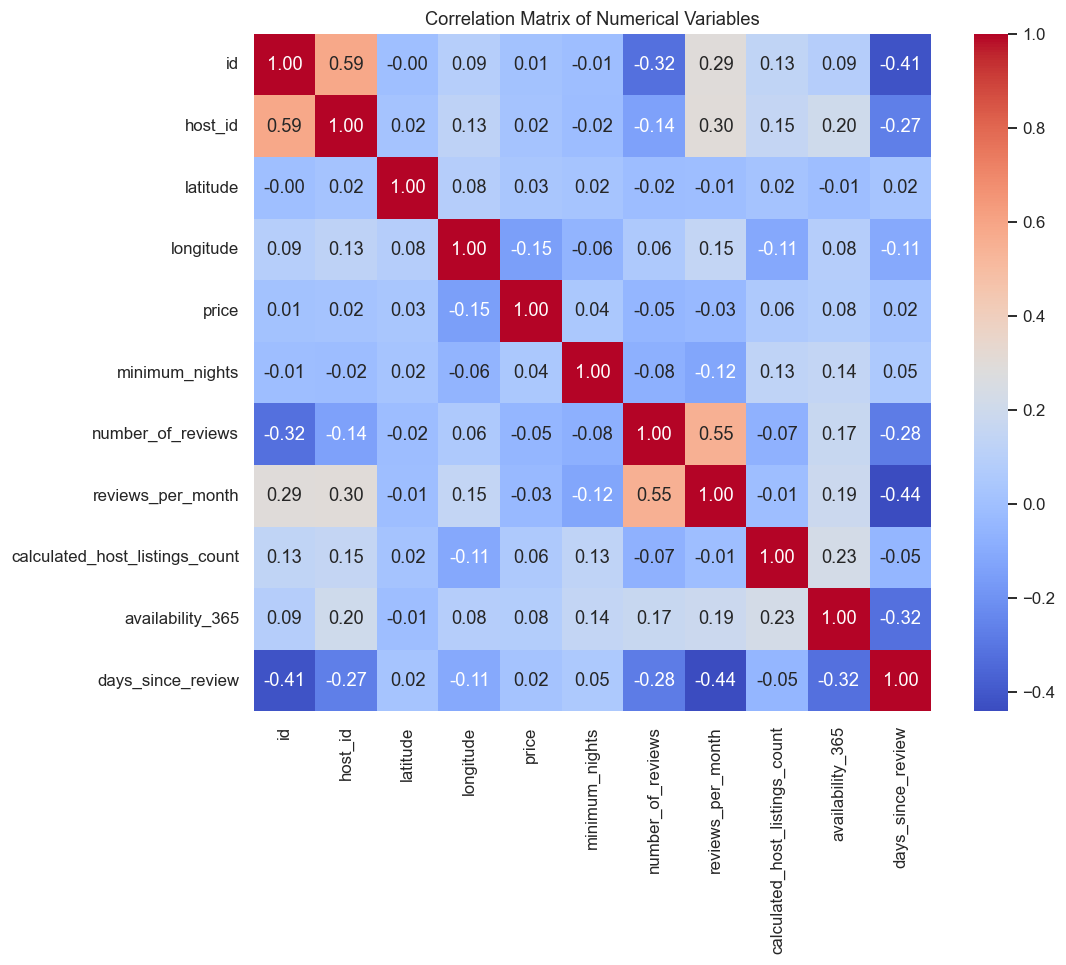

In [50]:
# Your code here
# Select only numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

# Compute correlation matrix
corr_matrix = df[num_cols].corr()

# Visualize using a heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

**✍️ Your Interpretation:**  

1. host_id-id, id-reviews_per_month, host_id-reviews_per_month, minimun_nights-calculated_host_listings_count, minimum_nights-availability_365, number_of_reviews-reviews_per_month, host_id-availability_365, number_of_reviews-availability_365, reviews_per_monyh-availability_365, calculated_host_listings_count-avaailability_365
2. an assumed threshold is 0.10 for a moderate correlation.
price is not correlated with number of reviews, which means that when one of the two quantities increases, the second one decreases, but the effect is negligible.
yes, price is directly correlated with availability 365, which means an increase in price leads to an increase in availability 365 and vice versa. but the correlation is weaker(0.08).
A correlation only shows that two variables move together in some way (positively or negatively). It does not mean one variable causes the other to change. For example, even if price and availability_365 are slightly correlated, it doesn’t mean higher prices cause more availability — there could be other factors like location, host preferences, or listing type influencing both.
3. no surprising correlations. 

### Task 5.2 — Pairplot Exploration (5 marks)

Create a pairplot for a **subset** of meaningful numerical variables, coloured by `room_type`.

- Choose 3–4 variables wisely and justify your selection.
- What clusters or separations between room types do you observe?

> 💡 *Hint: Including all columns in a pairplot makes it unreadable. Be intentional.
> Which variables have already proven interesting in earlier tasks?*


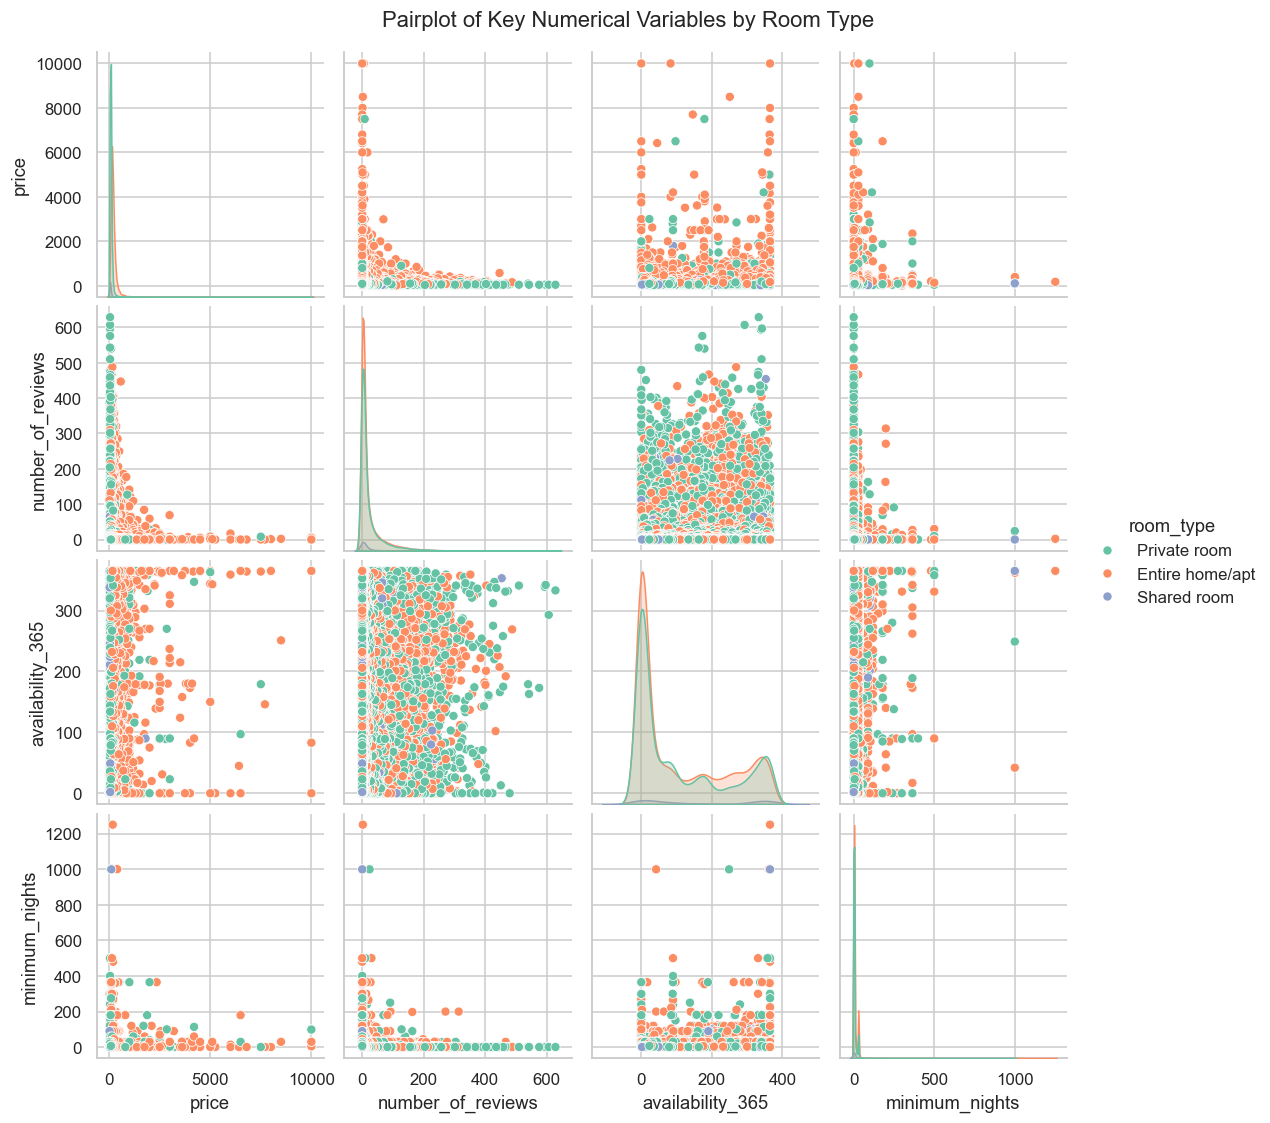

In [57]:
# Your code here
subset_cols = ['price', 'number_of_reviews', 'availability_365', 'minimum_nights']

# Pairplot coloured by room_type
sns.pairplot(df[subset_cols + ['room_type']], hue='room_type', palette='Set2', diag_kind='kde', height=2.5)
plt.suptitle("Pairplot of Key Numerical Variables by Room Type", y=1.02)
plt.show()

**✍️ Your Interpretation:**  
*(Write here)*


---

# 📋 PART 6 — Final Investor Brief
### (10 Marks)

Synthesise your findings into a **short written brief** (Markdown only — no new code needed).

Your audience is **non-technical investors**. Write 250–350 words covering:

1. **Data Quality Warning:** What issues did you find that an investor must know before trusting any numbers?
2. **Manhattan Investor:** Opportunities and risks based purely on your EDA.
3. **Brooklyn Investor:** Same question for Brooklyn.
4. **Undecided Investor:** If you had to recommend one borough and one room type
   for consistent rental income, what would it be and why?
5. **One thing you would investigate next** if given more time.

> ⚠️ *You will be graded on the quality of reasoning, not just whether code runs.
> A technically correct analysis with a weak interpretation earns fewer marks than a thoughtful one.*


**✍️ Your Investor Brief:**

---

### Data Quality Warnings
Some listings in the data are unusual. A few have very high prices or require 365 nights, which are really long-term or luxury rentals. Some have very few reviews, so it’s hard to tell if they are popular. Investors should focus on the normal short-term rentals for realistic numbers.

### Manhattan Investor
Manhattan offers the highest median prices, particularly for entire homes and apartments. Listings are dense in central neighborhoods, which can drive strong demand. The opportunity lies in premium pricing and high tourist appeal.

### Brooklyn Investor
Brooklyn listings generally have moderate prices with a growing demand in popular neighborhoods. Entire homes and private rooms perform well, though median prices are lower than Manhattan. The opportunity lies in more stable, less competitive markets with good occupancy rates. Risks include lower tourist density in some areas and more variation in availability. Brooklyn offers potential for consistent mid-range returns with lower initial investment compared to Manhattan.

### Recommendation for Undecided Investor
For investors seeking consistent short-term rental income, I would recommend entire homes or apartments in Manhattan. They offer the highest revenue potential, dense tourist demand, and clear separation from lower-priced room types. If budget or competition is a concern, Brooklyn entire homes provide a reasonable alternative with slightly lower risk. Filtering out long-minimum rentals is essential to ensure true short-term rental behavior.

### What I Would Investigate Next
Next, I’d look at seasonal trends—like which months are busiest and which listings get booked most often. This would help investors set prices smartly and plan for periods when demand is lower.

---


---

# 🌟 BONUS CHALLENGE — For Those Who Finish Early
### (Up to 10 extra marks)

Choose **one** of the following:

---

### Bonus A — The Power Host Hypothesis

Define power hosts as those with more than 5 listings.

- Do power hosts charge significantly different prices compared to single-listing hosts?
- Do they receive more or fewer reviews per month?
- Is there a borough where power hosts are unusually concentrated?

Build a mini-analysis with at least 3 visualisations and a 100-word written conclusion.

---

### Bonus B — Listing Name Text Analysis

The `name` column contains free-text titles written by hosts.

- What are the most common words in listing names overall? In each borough?
- Do listings with words like luxury, cozy, or spacious in their name charge more on average?
- Can you identify naming patterns that correlate with higher prices?

> 💡 *Hint: The `str` accessor in pandas lets you work with string columns directly.
> For word frequency, think about splitting sentences and counting individual words.*


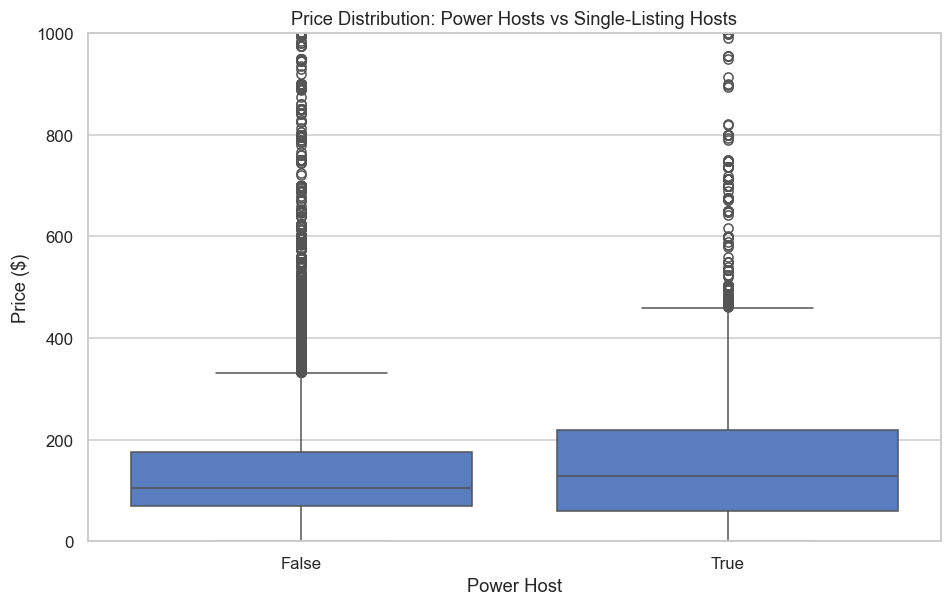

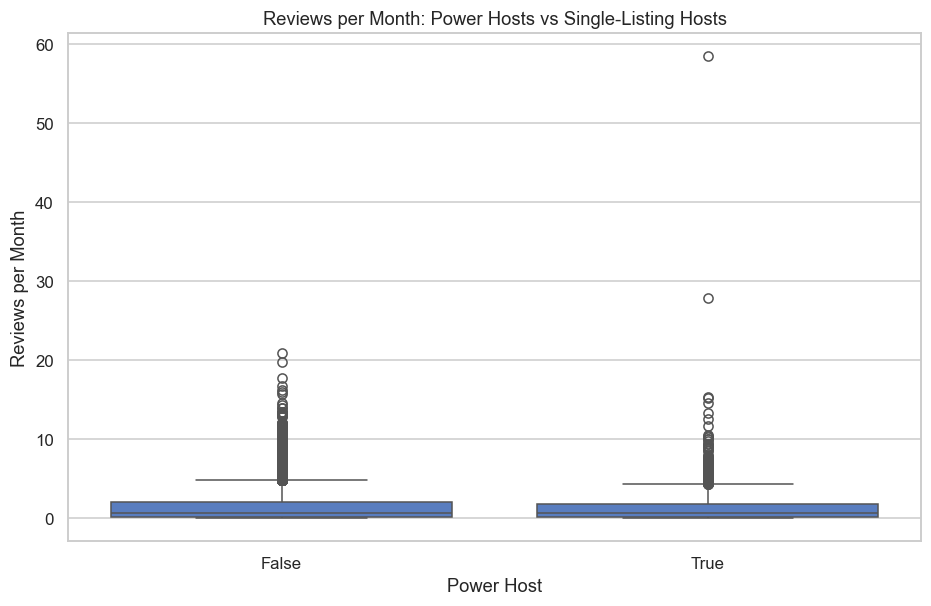

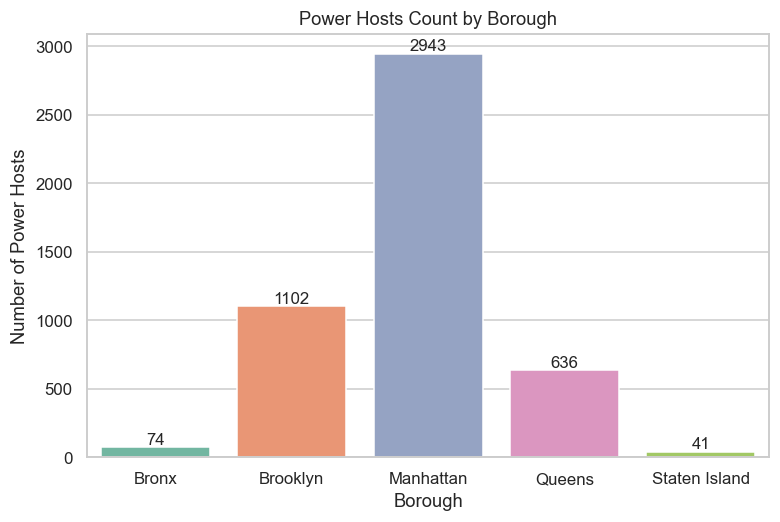

In [2]:
# Bonus code here (optional)
# Bonus A


host_counts = df.groupby('host_id').size().reset_index(name='listings_count')
df = df.merge(host_counts, on='host_id')
df['power_host'] = df['listings_count'] > 5

# Do power hosts charge significantly different prices compared to single-listing hosts?
plt.figure(figsize=(10,6))
sns.boxplot(x='power_host', y='price', data=df)
plt.ylim(0, 1000)  # optional for readability
plt.title('Price Distribution: Power Hosts vs Single-Listing Hosts')
plt.xlabel('Power Host')
plt.ylabel('Price ($)')
plt.show()


# Do they receive more or fewer reviews per month?
plt.figure(figsize=(10,6))
sns.boxplot(x='power_host', y='reviews_per_month', data=df)
plt.title('Reviews per Month: Power Hosts vs Single-Listing Hosts')
plt.xlabel('Power Host')
plt.ylabel('Reviews per Month')
plt.show()

# Is there a borough where power hosts are unusually concentrated?
borough_counts = df[df['power_host']].groupby('neighbourhood_group').size().reset_index(name='power_hosts_count')

plt.figure(figsize=(8,5))
ax = sns.barplot(x='neighbourhood_group', y='power_hosts_count', data=borough_counts, palette='Set2')

# Add numbers on top of bars
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.title('Power Hosts Count by Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Power Hosts')
plt.show()


**✍️ Bonus Interpretation:**  
Power hosts—those with more than five listings—tend to charge slightly higher prices than single-listing hosts, though extreme outliers exist. In terms of reviews per month, both power hosts and single-listing hosts receive roughly the same number, indicating that having multiple listings does not increase guest engagement per listing. Geographically, Manhattan shows the highest concentration of power hosts, followed by Brooklyn, highlighting that central locations attract professional multi-listing operators. Overall, power hosts differ mainly in pricing and location, while activity per listing remains similar to casual hosts, showing that scale does not necessarily mean higher individual listing performance.


---

## 📊 Marking Rubric

| Part | Description | Marks |
|------|-------------|-------|
| Part 1 | First Contact (Inspection, Nulls, Duplicates) | 15 |
| Part 2 | Price Analysis | 25 |
| Part 3 | Host Behaviour & Market Structure | 20 |
| Part 4 | Geographic Deep Dive | 20 |
| Part 5 | Correlation & Multivariate | 10 |
| Part 6 | Investor Brief (Written) | 10 |
| **Total** | | **100** |
| Bonus | Power Host or Text Analysis | +10 |

**Code quality counts.** Plots must have titles, axis labels, and legends where appropriate.  
All cells must run top-to-bottom without errors.

---
*Dataset: New York City Airbnb Open Data 2019 — sourced from Inside Airbnb via public GitHub mirror.*  
*This notebook is for educational purposes only.*
